# 📊 Vasicek Asset Correlation (ρ) Estimation

This notebook estimates the **asset correlation (ρ)** required for the Vasicek single-factor credit portfolio model.

The PD dataset spans **multiple years (2007–2014)**. To capture the effect of different economic conditions, the **observed default rates are first aggregated by year**.

These yearly default rates will then be used to estimate the **systematic asset correlation parameter (ρ)** used in the Vasicek framework.

### Steps

1. Import the prepared PD modelling dataset  
2. Extract and verify the **year variable**  
3. Aggregate **default rates by year**  
4. Use the time series of observed default rates to estimate **asset correlation (ρ)**

The estimated ρ will later be used in the **Vasicek Monte Carlo portfolio simulation**.

In [1]:
# ── Libraries ─────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Load dataset prepared in previous notebook ───────────
df = pd.read_pickle("../data/processed/vasicek_pd_data.pkl")

# ── Basic data check ─────────────────────────────────────
print("Dataset shape:", df.shape)

df.head()

Dataset shape: (230795, 2)


,year,default
0,2011,0
1,2011,1
2,2011,0
3,2011,0
4,2011,0


### Aggregate Observed Default Rates by Year

To estimate the Vasicek asset correlation parameter (ρ), we first compute the **observed default rate for each year**.

The annual default rate is defined as:

Default Rate = Number of Defaults in Year / Total Loans in Year

This produces a **time series of default rates**, which reflects how portfolio credit risk varies across different economic conditions.

These yearly default rates will later be used to estimate the **systematic asset correlation (ρ)** in the Vasicek single-factor model.

In [2]:
# ── Compute observed default rate by year ────────────────
yearly_default_rates = df.groupby('year')['default'].mean().reset_index()

yearly_default_rates.rename(columns={'default': 'default_rate'}, inplace=True)

yearly_default_rates

,year,default_rate
0,2007,0.262023
1,2008,0.207271
2,2009,0.136906
3,2010,0.140062
4,2011,0.163237
5,2012,0.163578
6,2013,0.210295
7,2014,0.210570


In [3]:
# ── Compute summary statistics of yearly default rates ──
mean_default_rate = yearly_default_rates['default_rate'].mean()
variance_default_rate = yearly_default_rates['default_rate'].var()

print("Mean Default Rate:", round(mean_default_rate, 4))
print("Variance of Default Rates:", round(variance_default_rate, 6))

Mean Default Rate: 0.1867
Variance of Default Rates: 0.001852


### Transform Default Rates Using the Vasicek Framework

In the Vasicek single-factor model, portfolio default rates are linked to a
latent systematic risk factor through the inverse standard normal
transformation.

For each year \(t\), the observed default rate \(p_t\) is transformed as:

X_t = Φ⁻¹(p_t)

where Φ⁻¹ is the inverse cumulative distribution function of the standard
normal distribution.

This transformation maps observed default rates into the **systematic risk
factor space**, allowing us to estimate the variability of the common economic
factor driving portfolio defaults.

In [4]:
from scipy.stats import norm

# ── Vasicek transformation ───────────────────────────────
yearly_default_rates['vasicek_factor'] = norm.ppf(yearly_default_rates['default_rate'])

yearly_default_rates

,year,default_rate,vasicek_factor
0,2007,0.262023,-0.637120
1,2008,0.207271,-0.815926
2,2009,0.136906,-1.094327
3,2010,0.140062,-1.080040
4,2011,0.163237,-0.981240
5,2012,0.163578,-0.979858
6,2013,0.210295,-0.805398
7,2014,0.210570,-0.804444


### Estimate Asset Correlation (ρ)

Under the Vasicek single-factor model, the systematic factor realization
in year t is:

    X_t = (Φ⁻¹(p_t) - √ρ · Φ⁻¹(p̄)) / √(1-ρ)

Since X_t ~ N(0,1) under the Vasicek framework, the variance of the systematic factor is 1. Under the assumption of a stable unconditional PD, this implies:

    Var(Φ⁻¹(p_t)) = ρ / (1 - ρ)

Solving for ρ:

    ρ = Var(Φ⁻¹(p_t)) / (1 + Var(Φ⁻¹(p_t)))

**Assumptions underlying this estimator:**
- Large homogeneous portfolio (idiosyncratic risk fully diversified)
- Stable unconditional PD across years (no structural trend)
- Single systematic factor, i.i.d. N(0,1) across years

**Limitations of this estimate:**
- Only 8 annual observations — variance estimate is statistically unstable
- LendingClub data spans the 2008 financial crisis — PD is not stable
- Loan volumes vary significantly by vintage year
- The result (ρ ≈ 0.025) should be treated as an indicative approximation
  consistent with typical Basel IRB retail correlation ranges (~0.01–0.05), not a precise estimate

For a production model, ρ would be estimated using Maximum Likelihood
Estimation (MLE) over a longer time series with explicit controls for
PD drift and portfolio composition changes.
This approach provides an intuitive link between observed default rate volatility and latent systematic risk, making it useful for exploratory analysis despite its limitations.

Var(Φ⁻¹(p_t))             : 0.0253
Estimated Asset Correlation: ρ ≈ 0.0247

Note: estimated from only 8 years of data.
Treat as an approximation — a longer time series would give a more stable estimate.


<Axes: title={'center': 'Latent Systematic Factor (Approx)'}, xlabel='year'>

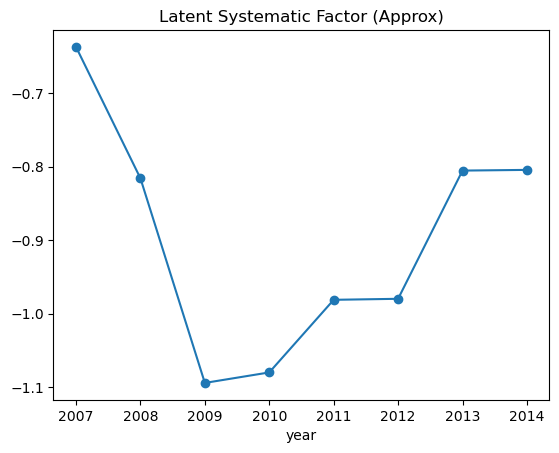

In [5]:
# Var(Φ⁻¹(p_t)) = ρ / (1 - ρ)  under the Vasicek single-factor model
# Solving for ρ:  ρ = var_x / (1 + var_x)

var_x = yearly_default_rates['vasicek_factor'].var()

rho_estimate = var_x / (1 + var_x)

print(f"Var(Φ⁻¹(p_t))             : {round(var_x, 4)}")
print(f"Estimated Asset Correlation: ρ ≈ {round(rho_estimate, 4)}")
print()
print("Note: estimated from only", len(yearly_default_rates), "years of data.")
print("Treat as an approximation — a longer time series would give a more stable estimate.")
yearly_default_rates.set_index('year')['vasicek_factor'].plot(
    title="Latent Systematic Factor (Approx)",
    marker='o'
)

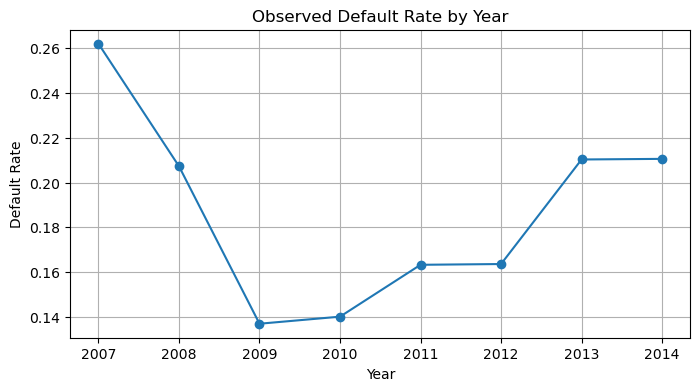

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(yearly_default_rates['year'], yearly_default_rates['default_rate'], marker='o')
plt.title("Observed Default Rate by Year")
plt.xlabel("Year")
plt.ylabel("Default Rate")
plt.grid(True)

plt.show()

## Interpretation

The observed variation in default rates across years reflects changing macroeconomic conditions affecting borrower credit quality.

Using the Vasicek framework, this variation translates into an estimated asset correlation of ρ ≈ 0.025, indicating relatively low but non-zero dependence among borrower defaults typical of retail credit portfolios.

However, this dataset spans the 2008 financial crisis and subsequent recovery period, during which default rates exhibit structural shifts. As a result, the estimated correlation captures not only systematic risk but also temporal changes in portfolio composition and macroeconomic conditions.

Therefore, the estimated ρ should be interpreted as an approximate empirical measure rather than a structural parameter of the Vasicek model.